Voy a hacer un cálculo teórico del ancho de la zona de carga espacial y la barrera de potencial para el InP y luego hago simulaciones en nanohub

In [2]:
import numpy as np
import matplotlib.pyplot as plt

In [3]:
k = 1.38e-23  # Boltzmann constant in J/K
T = 300  # Temperature in K
q = 1.6e-19  # Elementary charge in C

Nasga = 3.96e22  # atomic density of GaAs in atoms/cm^3
ni = 1.3e7  # intrinsic carrier concentration of GaAs in cm^-3
epsilonr = 12.5  # relative permittivity of GaAs
epsilon0 = 8.85e-14  # vacuum permittivity in F/cm

limit = 100000.0 # limit for the doping density in cm^-3

Na = Nasga / limit
Nd = Nasga / limit
print(f"Na: {Na:.2e} cm^-3, Nd: {Nd:.2e} cm^-3")


Na: 3.96e+17 cm^-3, Nd: 3.96e+17 cm^-3


$$
V_b = \frac{kT}{q}\ln\left(\frac{N_A N_D}{n_i^2}\right)
$$


$$W = \sqrt{\frac{2\varepsilon}{q}\left(\frac{1}{N_A}+\frac{1}{N_D}\right)V_b}$$

In [4]:
Vb = (k * T / q) * np.log((Na * Nd) / (ni ** 2))
W = np.sqrt((2 * epsilonr * epsilon0 / q) * (1 / Na + 1 / Nd) * Vb) * 1e7  # Convert from cm to nm
print(f"Built-in potential (Vb): {Vb:.2f} V")
print(f"Depletion width (W): {W:.2f} nm")

Built-in potential (Vb): 1.25 V
Depletion width (W): 93.41 nm


$$x_p = \sqrt{\frac{2\varepsilon}{q}\frac{N_D}{N_A(N_A+N_D)}V_b}$$

$$x_n = \sqrt{\frac{2\varepsilon}{q}\frac{N_A}{N_D(N_A+N_D)}V_b}$$

In [5]:
xp = np.sqrt(2 * epsilonr * epsilon0 * Vb * Nd / (q * Na * (Na + Nd))) * 1e4  # Convert from cm to nm
xn = np.sqrt(2 * epsilonr * epsilon0 * Vb * Na / (q * Nd * (Na + Nd))) * 1e4  # Convert from cm to nm
print(f"Depletion width on p-side (xp): {xp:.4f} μm")
print(f"Depletion width on n-side (xn): {xn:.4f} μm")

Depletion width on p-side (xp): 0.0467 μm
Depletion width on n-side (xn): 0.0467 μm


Ahora metemos estas condiciones en el simulador y vemos si se cumple

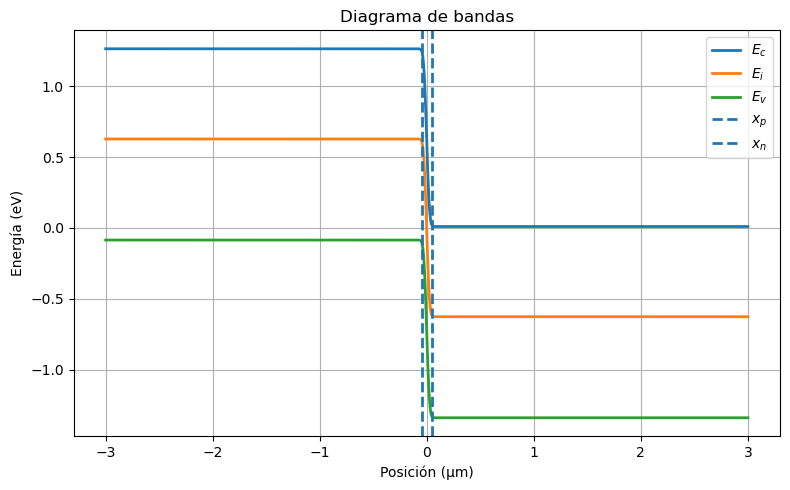

In [15]:

# =========================
# LEER ARCHIVOS
# =========================

# Los archivos tienen cabecera:
# Position (um), Energy (eV)
Ec = np.loadtxt("Ec1.txt", delimiter=",", skiprows=1)
Ei = np.loadtxt("Ei1.txt", delimiter=",", skiprows=1)
Ev = np.loadtxt("Ev1.txt", delimiter=",", skiprows=1)

# =========================
# SEPARAR COLUMNAS
# =========================

x_Ec = Ec[:, 0] -3.0  # posición en micras
y_Ec = Ec[:, 1]    # energía en eV

x_Ei = Ei[:, 0] -3.0
y_Ei = Ei[:, 1] 

x_Ev = Ev[:, 0] -3.0
y_Ev = Ev[:, 1] 

# =========================
# LÍNEAS VERTICALES
# =========================
# Cambia estos valores cuando tengas xp y xn



# =========================
# PLOT
# =========================

plt.figure(figsize=(8, 5))

plt.plot(x_Ec, y_Ec, label=r"$E_c$", linewidth=2)
plt.plot(x_Ei, y_Ei, label=r"$E_i$", linewidth=2)
plt.plot(x_Ev, y_Ev, label=r"$E_v$", linewidth=2)

# Líneas verticales
plt.axvline(x=-xp , linestyle="--", linewidth=2, label=r"$x_p$")
plt.axvline(x=xn , linestyle="--", linewidth=2, label=r"$x_n$")

plt.xlabel("Posición (µm)")
plt.ylabel("Energía (eV)")
plt.title("Diagrama de bandas")
plt.grid(True)
plt.legend()
plt.tight_layout()

plt.show()

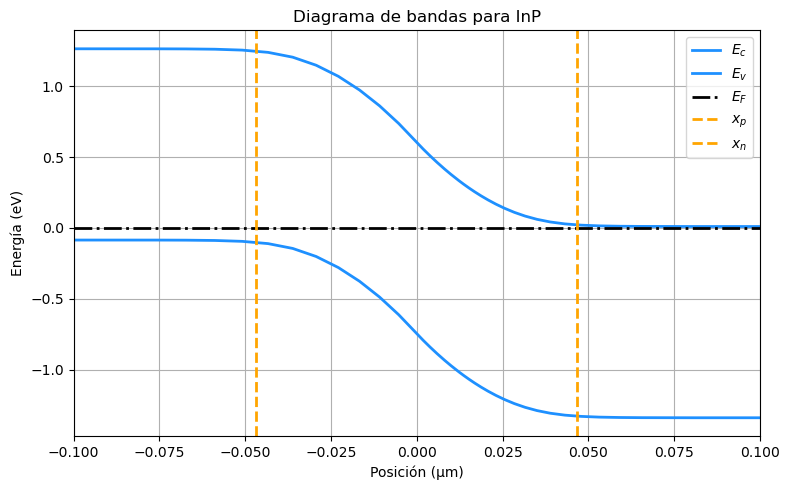

In [26]:
plt.figure(figsize=(8, 5))

plt.plot(x_Ec, y_Ec, label=r"$E_c$", linewidth=2, color="dodgerblue")

plt.plot(x_Ev, y_Ev, label=r"$E_v$", linewidth=2, color="dodgerblue")
plt.axhline(y = 0 , linestyle="-.", linewidth=2, label=r"$E_F$",color ="black")


plt.axvline(x=-xp , linestyle="--", linewidth=2, label=r"$x_p$", color="orange")
plt.axvline(x=xn , linestyle="--", linewidth=2, label=r"$x_n$", color="orange")

plt.xlim(-0.1,0.1)

plt.xlabel("Posición (µm)")
plt.ylabel("Energía (eV)")
plt.title("Diagrama de bandas para InP")
plt.grid(True)
plt.legend()
plt.tight_layout()

plt.show()

si este es el máximo vamos apañaos si los gnomos son nanométricos...

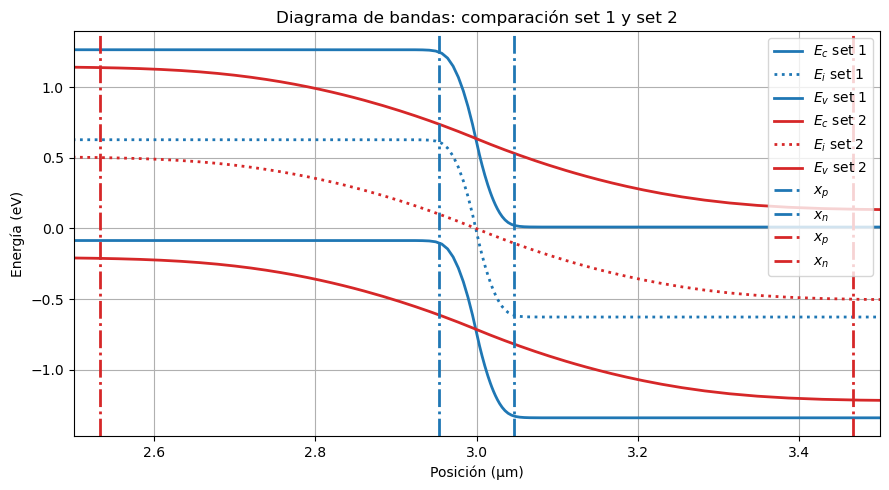

In [8]:

# =========================
# FUNCIÓN PARA LEER ARCHIVOS
# =========================

def leer_archivo(nombre):
    datos = np.loadtxt(nombre, delimiter=",", skiprows=1)
    x = datos[:, 0]
    y = datos[:, 1]
    return x, y


# =========================
# LEER SET 1
# =========================

x_Ec1, y_Ec1 = leer_archivo("Ec1.txt")
x_Ei1, y_Ei1 = leer_archivo("Ei1.txt")
x_Ev1, y_Ev1 = leer_archivo("Ev1.txt")


# =========================
# LEER SET 2
# =========================

x_Ec2, y_Ec2 = leer_archivo("Ec2.txt")
x_Ei2, y_Ei2 = leer_archivo("Ei2.txt")
x_Ev2, y_Ev2 = leer_archivo("Ev2.txt")


# =========================
# POSICIÓN DE LA UNIÓN Y LÍNEAS VERTICALES
# =========================
# Cambia estos valores a los tuyos

x_union = 3.0  # micras

xp1 = np.sqrt(2 * epsilonr * epsilon0 * Vb * Nd / (q * Na * (Na + Nd))) * 1e4      # anchura hacia el lado p, en micras
xn1 = np.sqrt(2 * epsilonr * epsilon0 * Vb * Na / (q * Nd * (Na + Nd))) * 1e4      # anchura hacia el lado n, en micras

Na2 = Nasga / (limit * 100.0)
Nd2 = Nasga / (limit * 100.0)

xp2 = np.sqrt(2 * epsilonr * epsilon0 * Vb * Nd2 / (q * Na2 * (Na2 + Nd2))) * 1e4
xn2 = np.sqrt(2 * epsilonr * epsilon0 * Vb * Na2 / (q * Nd2 * (Na2 + Nd2))) * 1e4



x_linea_p1 = x_union - xp1
x_linea_n1 = x_union + xn1
x_linea_p2 = x_union - xp2
x_linea_n2 = x_union + xn2


# =========================
# COLORES
# =========================

color_set1 = "tab:blue"
color_set2 = "tab:red"


# =========================
# PLOT
# =========================

plt.figure(figsize=(9, 5))

# ---------- SET 1 ----------
plt.plot(x_Ec1, y_Ec1, color=color_set1, linestyle="-", linewidth=2,
         label=r"$E_c$ set 1")

plt.plot(x_Ei1, y_Ei1, color=color_set1, linestyle=":", linewidth=2,
         label=r"$E_i$ set 1")

plt.plot(x_Ev1, y_Ev1, color=color_set1, linestyle="-", linewidth=2,
         label=r"$E_v$ set 1")


# ---------- SET 2 ----------
plt.plot(x_Ec2, y_Ec2, color=color_set2, linestyle="-", linewidth=2,
         label=r"$E_c$ set 2")

plt.plot(x_Ei2, y_Ei2, color=color_set2, linestyle=":", linewidth=2,
         label=r"$E_i$ set 2")

plt.plot(x_Ev2, y_Ev2, color=color_set2, linestyle="-", linewidth=2,
         label=r"$E_v$ set 2")


# ---------- LÍNEAS VERTICALES ----------
plt.axvline(x=x_linea_p1, color=color_set1, linestyle="-.", linewidth=2,
            label=r"$x_p$")

plt.axvline(x=x_linea_n1, color=color_set1, linestyle="-.", linewidth=2,
            label=r"$x_n$")
plt.axvline(x=x_linea_p2, color=color_set2, linestyle="-.", linewidth=2,
            label=r"$x_p$")

plt.axvline(x=x_linea_n2, color=color_set2, linestyle="-.", linewidth=2,
            label=r"$x_n$")


# =========================
# AJUSTES DEL PLOT
# =========================

plt.xlim(2.5,3.5)

plt.xlabel("Posición (µm)")
plt.ylabel("Energía (eV)")
plt.title("Diagrama de bandas: comparación set 1 y set 2")

plt.grid(True)
plt.legend()
plt.tight_layout()

plt.show()